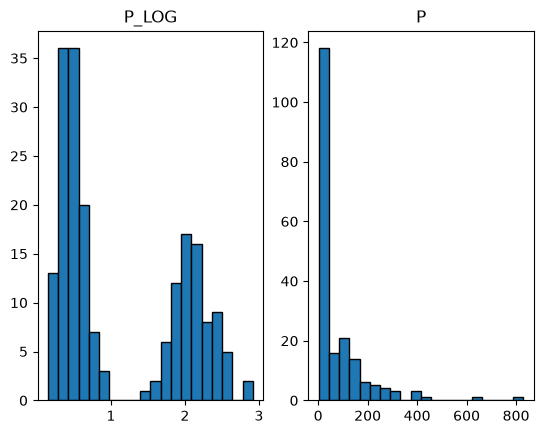

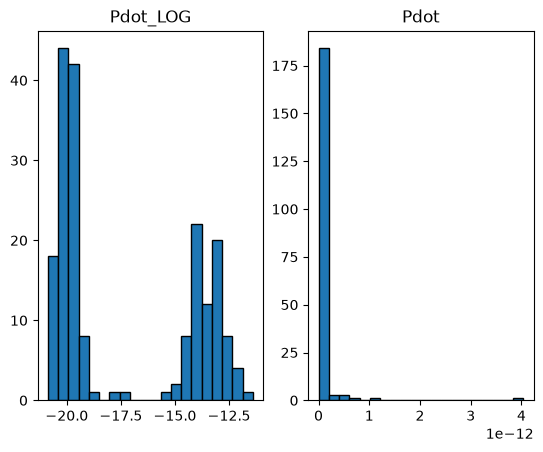

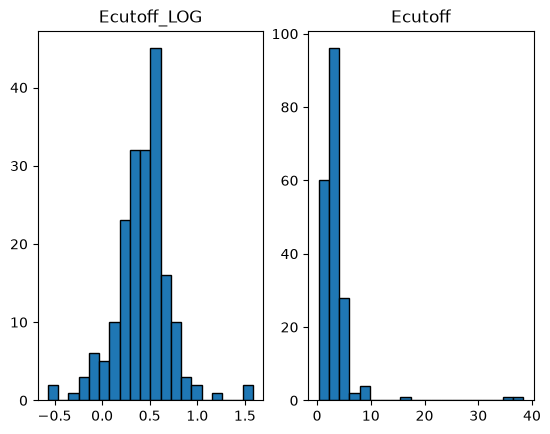

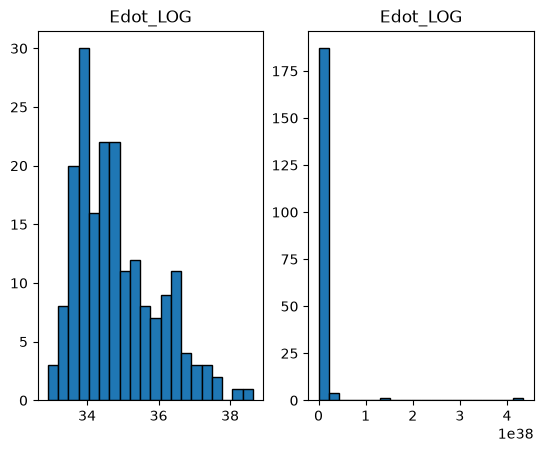

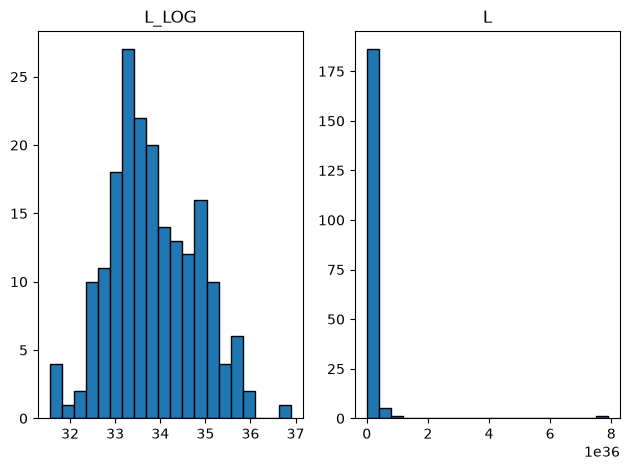

In [60]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Read the data from the file
df = pd.read_csv('pulsar_verisi_data9file.csv')

# Log versiyonu
P_log = np.log10(df['P'])
Pdot_log = np.log10(df['PdotCor'])
Ecutoff_log = np.log10(df['ECut_HYB'])
Edot_log = np.log10(df['EdotCor'])
Bdot_log = np.log10(df['BdotS,Cor'])
L_log = np.log10(df['LUMG'])

#Normal versiyonu
P = df['P']
Pdot = df['PdotCor']
Ecutoff = df['ECut_HYB']
Edot = df['EdotCor']
Bdot = df['BdotS,Cor']
L = df['LUMG']


#Distributions
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.hist(P_log, bins=20, edgecolor='black')
ax2.hist(P, bins=20, edgecolor='black')
ax1.set_title('P_LOG')
ax2.set_title('P')
fig, (ax3, ax4) = plt.subplots(1, 2)
ax3.hist(Pdot_log, bins=20, edgecolor='black')
ax4.hist(Pdot, bins=20, edgecolor='black')
ax3.set_title('Pdot_LOG')
ax4.set_title('Pdot')
fig, (ax5, ax6) = plt.subplots(1, 2)
ax5.hist(Ecutoff_log, bins=20, edgecolor='black')
ax6.hist(Ecutoff, bins=20, edgecolor='black')
ax5.set_title('Ecutoff_LOG')
ax6.set_title('Ecutoff')
fig, (ax7, ax8) = plt.subplots(1, 2)
ax7.hist(Edot_log, bins=20, edgecolor='black')
ax8.hist(Edot, bins=20, edgecolor='black')
ax7.set_title('Edot_LOG')
ax8.set_title('Edot_LOG')
fig, (ax9, ax10) = plt.subplots(1, 2)
ax9.hist(L_log, bins=20, edgecolor='black')
ax10.hist(L, bins=20, edgecolor='black')
ax9.set_title('L_LOG')
ax10.set_title('L')
plt.tight_layout()
plt.show()




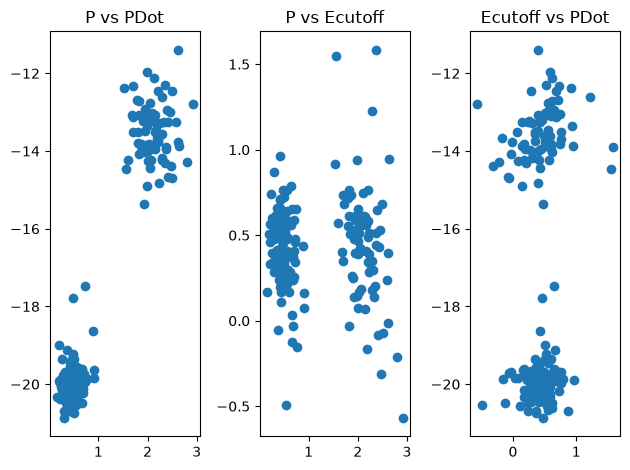

In [61]:
# Correlations
fig, (ax1,ax2,ax3) = plt.subplots(1,3)
ax1.scatter(P_log, Pdot_log)
ax2.scatter(P_log, Ecutoff_log)
ax3.scatter(Ecutoff_log, Pdot_log)
ax1.set_title('P vs PDot')
ax2.set_title('P vs Ecutoff')
ax3.set_title('Ecutoff vs PDot')
plt.tight_layout()
plt.show()

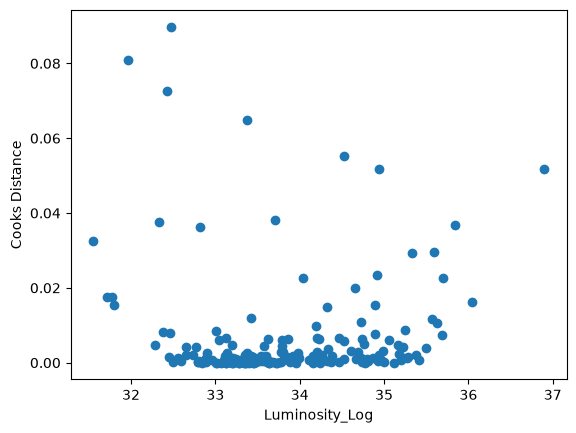

184


In [65]:


# Fitting: L ~ Ecutoff + Edot + Bdot + constant
df_filtrelenmis = df[df['n_ECut_HYB'] > 4].copy()
L_log_yeni = np.log10(df_filtrelenmis['LUMG'])
Ecutoff_log_yeni = np.log10(df_filtrelenmis['ECut_HYB'])
Edot_log_yeni = np.log10(df_filtrelenmis['EdotCor'])
Bdot_log_yeni = np.log10(df_filtrelenmis['BdotS,Cor'])
X = pd.concat([Ecutoff_log_yeni, Edot_log_yeni,Bdot_log_yeni], axis=1)
X = sm.add_constant(X)
model = sm.OLS(L_log_yeni,X).fit()
np.set_printoptions(suppress=True)

#create instance of influence
influence = model.get_influence()

#obtain Cook's distance for each observation
cooks = influence.cooks_distance

#display Cook's distances
#print(cooks)
plt.scatter(L_log_yeni, cooks[0])
plt.xlabel('Luminosity_Log')
plt.ylabel('Cooks Distance')
plt.show()

print(len(df_filtrelenmis))
